In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
#CELL 1 — Install Libraries
!pip install -q tensorflow xgboost scikit-learn matplotlib seaborn

In [4]:
#CELL 2 — Imports
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import (
    EfficientNetB0,
    VGG16,
    ResNet50
)

from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    matthews_corrcoef,
    roc_curve,
    auc,
    precision_recall_curve,
    classification_report
)

2026-05-14 17:01:35.610052: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778778095.806092      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778778095.861269      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778778096.337866      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778778096.337913      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778778096.337915      57 computation_placer.cc:177] computation placer alr

In [5]:
#CELL 3 — Download Dataset
!kaggle competitions download -c aptos2019-blindness-detection --force

!unzip -q -o aptos2019-blindness-detection.zip -d aptos_data


100%|██████████████████████████████████████| 9.51G/9.51G [05:40<00:00, 30.0MB/s]



In [6]:
#CELL 4 — Load Dataset
train_csv = pd.read_csv(
    'aptos_data/train.csv'
)

train_path = 'aptos_data/train_images'

train_csv.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [7]:
#CELL 5 — Binary Labels
train_csv['binary_label'] = train_csv['diagnosis'].apply(
    lambda x: 0 if x == 0 else 1
)

train_csv.head()

,id_code,diagnosis,binary_label
0,000c1434d8d7,2,1
1,001639a390f0,4,1
2,0024cdab0c1e,1,1
3,002c21358ce6,0,0
4,005b95c28852,0,0


In [8]:
#CELL 6 — Settings
IMG_SIZE = (224,224)

In [9]:
#CELL 7 — Preprocessing
def preprocess_image(image_path):

    img = tf.io.read_file(image_path)

    img = tf.image.decode_png(
        img,
        channels=3
    )

    img = tf.image.resize(
        img,
        IMG_SIZE
    )

    img = tf.cast(
        img,
        tf.float32
    ) / 255.0

    return img

In [10]:
#CELL 8 — Load Images
X = []
y = []

for i in range(3000):

    img_name = train_csv.iloc[i]['id_code']

    label = train_csv.iloc[i]['binary_label']

    path = os.path.join(
        train_path,
        img_name + '.png'
    )

    img = preprocess_image(path)

    X.append(img.numpy())

    y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

I0000 00:00:1778778540.288784      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


(3000, 224, 224, 3)
(3000,)


In [11]:
#CELL 9 — Split Data
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
#CELL 10 — Feature Extraction Function
def extract_features(model_name):

    if model_name == 'EfficientNetB0':

        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == 'VGG16':

        base_model = VGG16(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == 'ResNet50':

        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=(224,224,3)
        )

    feature_extractor = Model(
        inputs=base_model.input,
        outputs=base_model.output
    )

    train_features = feature_extractor.predict(
        X_train
    )

    val_features = feature_extractor.predict(
        X_val
    )

    train_features = train_features.reshape(
        train_features.shape[0],
        -1
    )

    val_features = val_features.reshape(
        val_features.shape[0],
        -1
    )

    return train_features, val_features

In [13]:
#CELL 11 — MRMR Feature Selection
def apply_mrmr(
    X_train_feat,
    y_train,
    X_val_feat
):

    selector = SelectKBest(
        score_func=mutual_info_classif,
        k=1000
    )

    X_train_selected = selector.fit_transform(
        X_train_feat,
        y_train
    )

    X_val_selected = selector.transform(
        X_val_feat
    )

    return X_train_selected, X_val_selected

In [14]:
#CELL 12 — ML Models
ml_models = {

    'SVM': SVC(
        kernel='rbf',
        probability=True,
        C=10
    ),

    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        eval_metric='logloss'
    ),

    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [15]:
#CELL 13 — Metrics Function
def calculate_metrics(
    y_true,
    y_pred,
    y_prob,
    model_name
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp)

    print(f"\n{model_name}")

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1)
    print("Specificity:", specificity)
    print("MCC:", mcc)

    print(classification_report(
        y_true,
        y_pred
    ))

    # ROC Curve
    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob[:,1]
    )

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))

    plt.plot(
        fpr,
        tpr,
        label=f'AUC = {roc_auc:.2f}'
    )

    plt.plot([0,1],[0,1],'--')

    plt.xlabel('FPR')

    plt.ylabel('TPR')

    plt.title(model_name + ' ROC Curve')

    plt.legend()

    plt.show()

    # PR Curve
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_true,
        y_prob[:,1]
    )

    plt.figure(figsize=(6,5))

    plt.plot(
        recall_curve,
        precision_curve
    )

    plt.xlabel('Recall')

    plt.ylabel('Precision')

    plt.title(model_name + ' PR Curve')

    plt.show()

    return accuracy


Running EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


I0000 00:00:1778778777.645768     131 service.cc:152] XLA service 0x7f4da8003390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778778777.645823     131 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778778778.563372     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778778785.089927     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 505ms/step

EfficientNetB0 + SVM

EfficientNetB0_SVM
Accuracy: 0.855
Precision: 0.8005390835579514
Recall: 0.9580645161290322
F1-Score: 0.8722466960352423
Specificity: 0.7448275862068966
MCC: 0.7230424798694738
              precision    recall  f1-score   support

           0       0.94      0.74      0.83       290
           1       0.80      0.96      0.87       310

    accuracy                           0.85       600
   macro avg       0.87      0.85      0.85       600
weighted avg       0.87      0.85      0.85       600



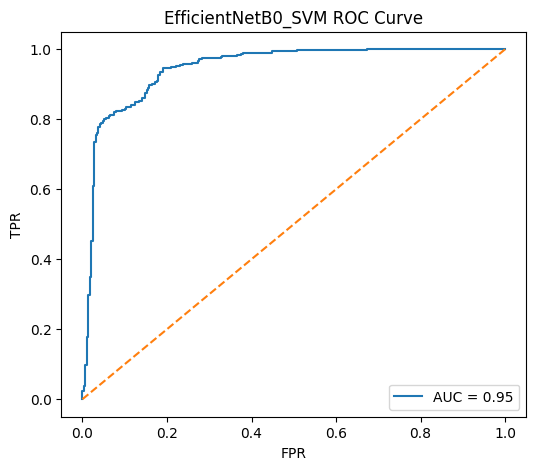

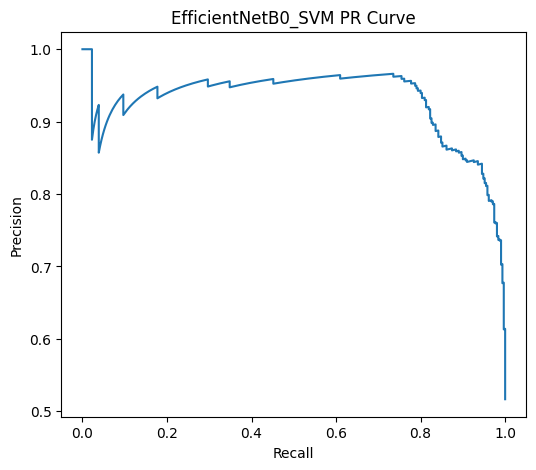


EfficientNetB0 + RandomForest

EfficientNetB0_RandomForest
Accuracy: 0.9416666666666667
Precision: 0.939297124600639
Recall: 0.9483870967741935
F1-Score: 0.9438202247191011
Specificity: 0.9344827586206896
MCC: 0.8832088604521173
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       290
           1       0.94      0.95      0.94       310

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



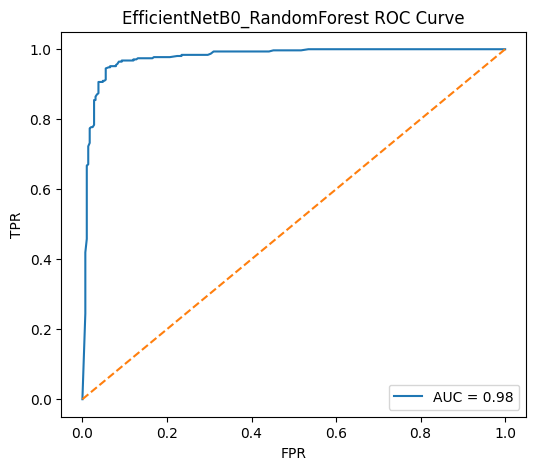

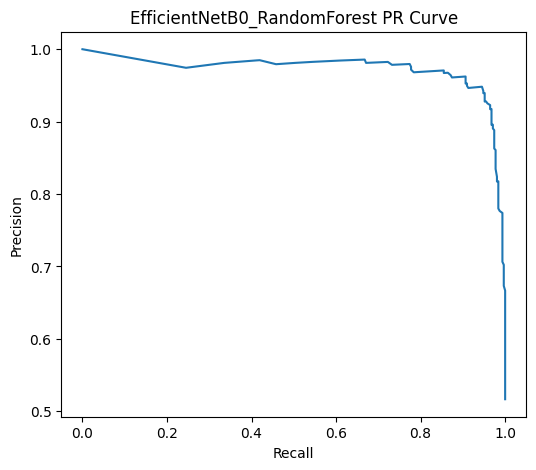


EfficientNetB0 + XGBoost

EfficientNetB0_XGBoost
Accuracy: 0.9466666666666667
Precision: 0.9483870967741935
Recall: 0.9483870967741935
F1-Score: 0.9483870967741935
Specificity: 0.9448275862068966
MCC: 0.8932146829810901
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       290
           1       0.95      0.95      0.95       310

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600



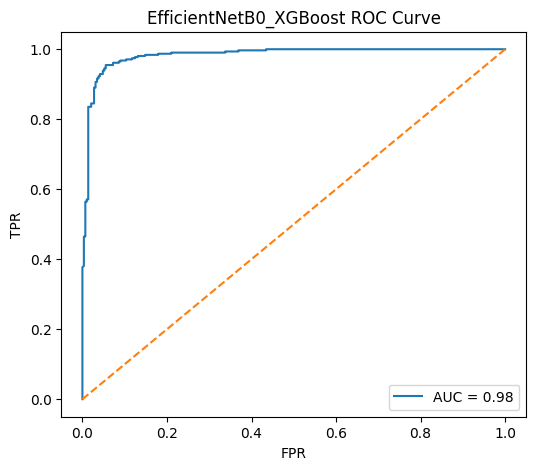

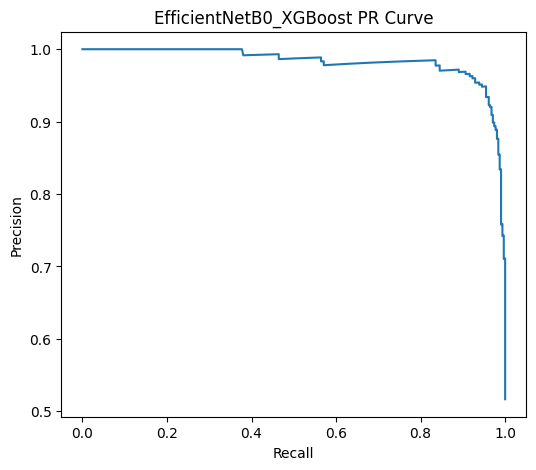


EfficientNetB0 + AdaBoost

EfficientNetB0_AdaBoost
Accuracy: 0.925
Precision: 0.9288025889967637
Recall: 0.9258064516129032
F1-Score: 0.9273021001615509
Specificity: 0.9241379310344827
MCC: 0.8498545807343668
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       290
           1       0.93      0.93      0.93       310

    accuracy                           0.93       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.93      0.93      0.93       600



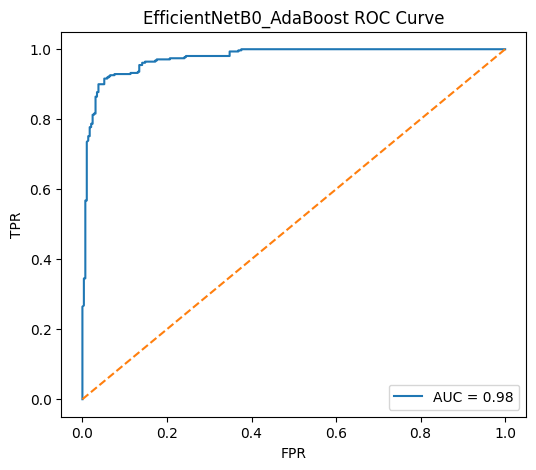

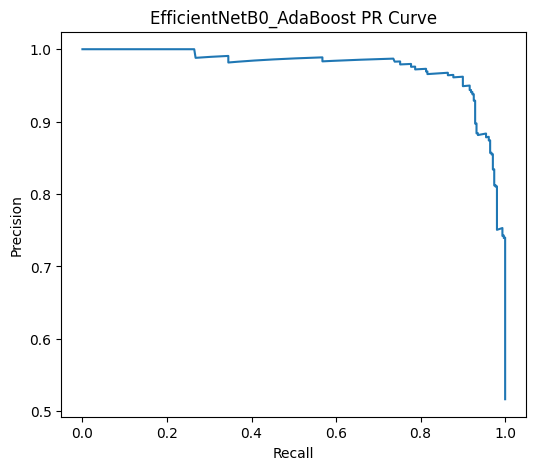


Running VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 380ms/step

VGG16 + SVM

VGG16_SVM
Accuracy: 0.945
Precision: 0.9511400651465798
Recall: 0.9419354838709677
F1-Score: 0.946515397082658
Specificity: 0.9482758620689655
MCC: 0.8899589462125899
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       290
           1       0.95      0.94      0.95       310

    accuracy                           0.94       600
   macro avg       0.94      0.95      0.94       600
weighted avg       0.95      0.94      0.95       600



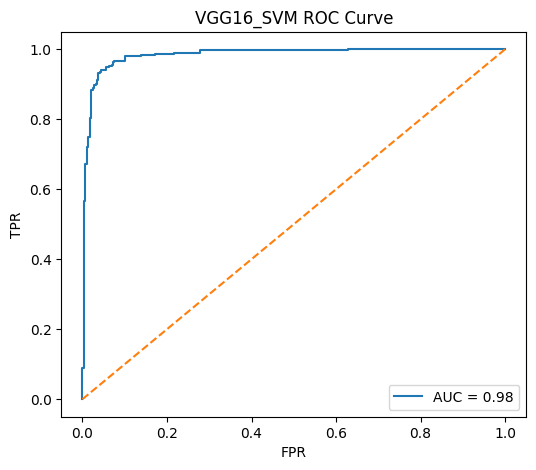

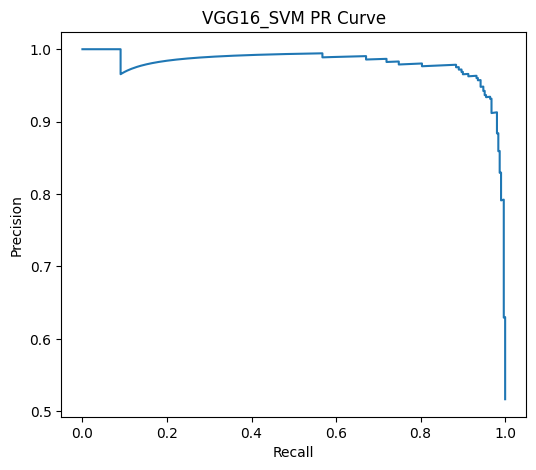


VGG16 + RandomForest

VGG16_RandomForest
Accuracy: 0.9433333333333334
Precision: 0.948051948051948
Recall: 0.9419354838709677
F1-Score: 0.9449838187702265
Specificity: 0.9448275862068966
MCC: 0.8865855734926197
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       290
           1       0.95      0.94      0.94       310

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



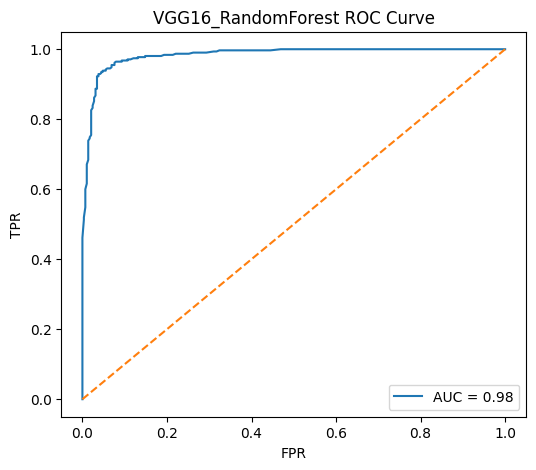

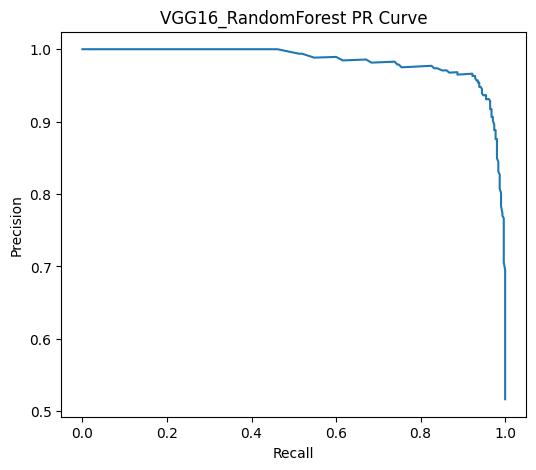


VGG16 + XGBoost

VGG16_XGBoost
Accuracy: 0.955
Precision: 0.9609120521172638
Recall: 0.9516129032258065
F1-Score: 0.9562398703403565
Specificity: 0.9586206896551724
MCC: 0.9099755162885946
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       290
           1       0.96      0.95      0.96       310

    accuracy                           0.95       600
   macro avg       0.95      0.96      0.95       600
weighted avg       0.96      0.95      0.96       600



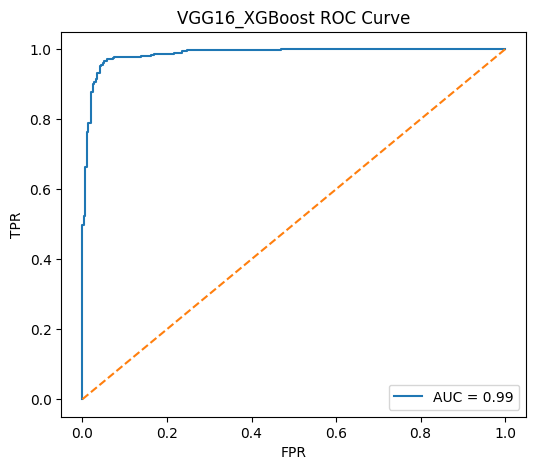

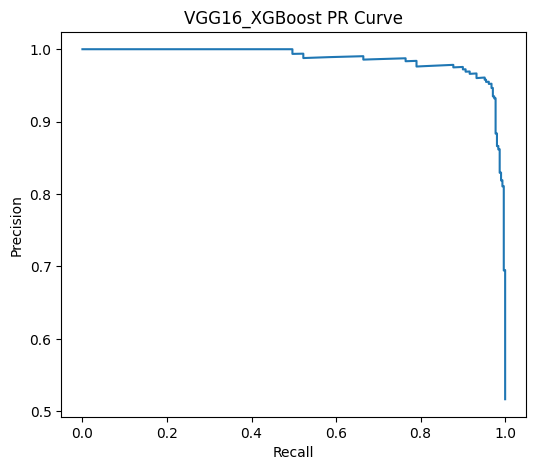


VGG16 + AdaBoost

VGG16_AdaBoost
Accuracy: 0.9366666666666666
Precision: 0.9358974358974359
Recall: 0.9419354838709677
F1-Score: 0.9389067524115756
Specificity: 0.9310344827586207
MCC: 0.8731836751049303
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       290
           1       0.94      0.94      0.94       310

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



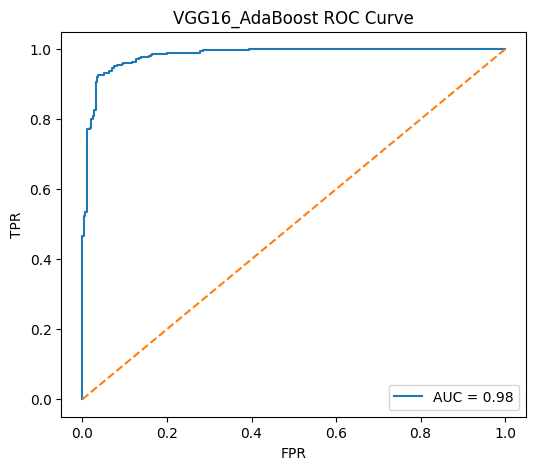

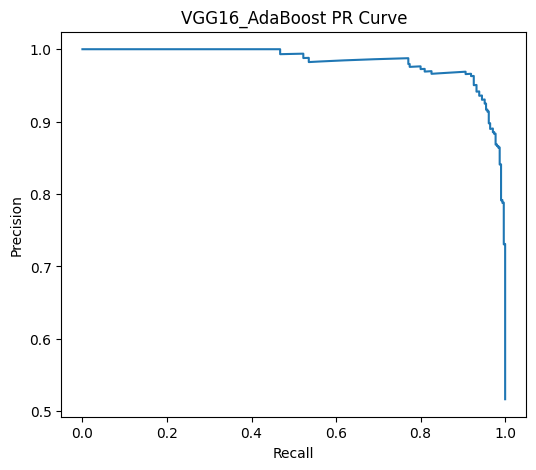


Running ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step

ResNet50 + SVM

ResNet50_SVM
Accuracy: 0.895
Precision: 0.8579710144927536
Recall: 0.9548387096774194
F1-Score: 0.9038167938931297
Specificity: 0.8310344827586207
MCC: 0.7944245974190637
              precision    recall  f1-score   support

           0       0.95      0.83      0.88       290
           1       0.86      0.95      0.90       310

    accuracy                           0.90       600
   macro avg       0.90      0.89      0.89       600
weighted avg       0.90      0.90      0.89       600



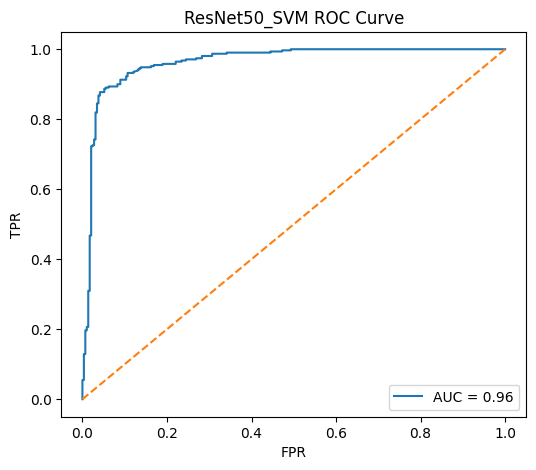

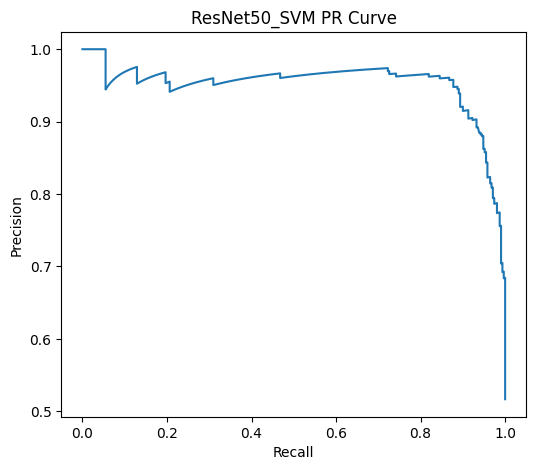


ResNet50 + RandomForest

ResNet50_RandomForest
Accuracy: 0.9466666666666667
Precision: 0.9483870967741935
Recall: 0.9483870967741935
F1-Score: 0.9483870967741935
Specificity: 0.9448275862068966
MCC: 0.8932146829810901
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       290
           1       0.95      0.95      0.95       310

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600



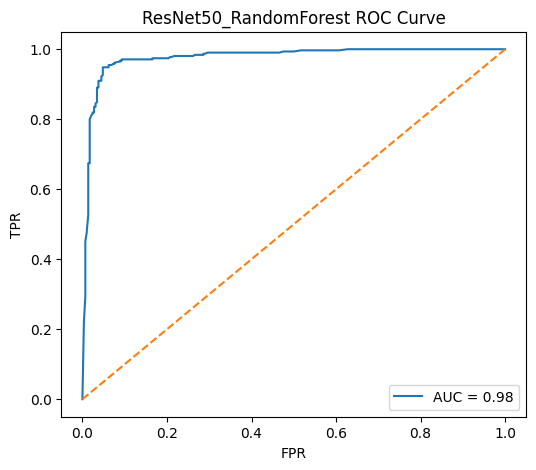

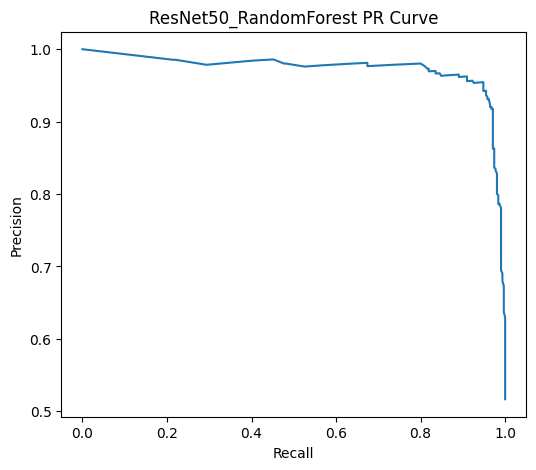


ResNet50 + XGBoost

ResNet50_XGBoost
Accuracy: 0.95
Precision: 0.9487179487179487
Recall: 0.9548387096774194
F1-Score: 0.9517684887459807
Specificity: 0.9448275862068966
MCC: 0.8998865397870384
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       290
           1       0.95      0.95      0.95       310

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600



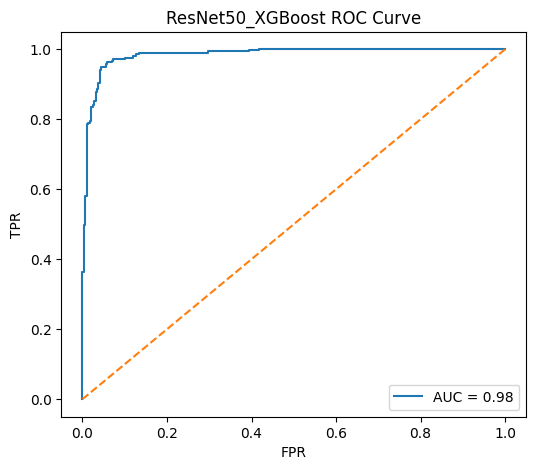

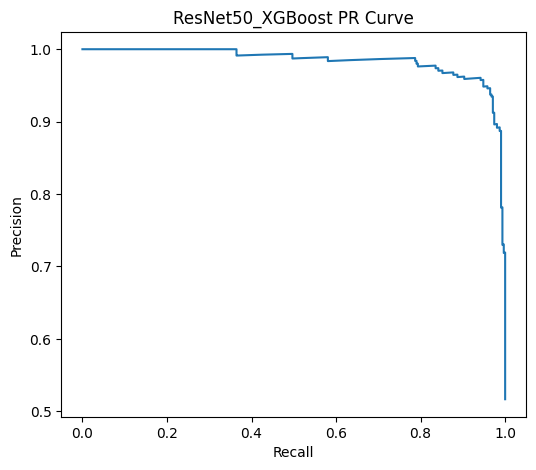


ResNet50 + AdaBoost

ResNet50_AdaBoost
Accuracy: 0.9416666666666667
Precision: 0.9337539432176656
Recall: 0.9548387096774194
F1-Score: 0.9441786283891547
Specificity: 0.9275862068965517
MCC: 0.8833539585028434
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       290
           1       0.93      0.95      0.94       310

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



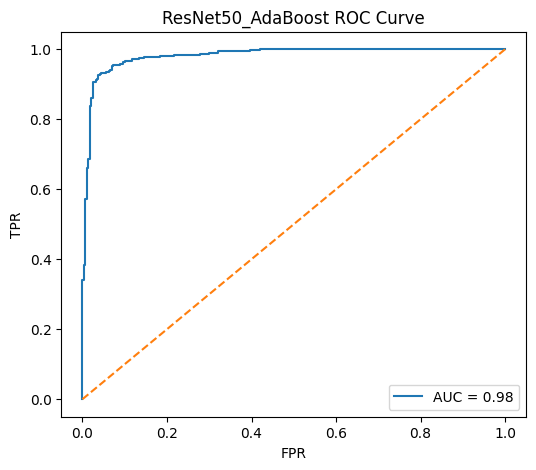

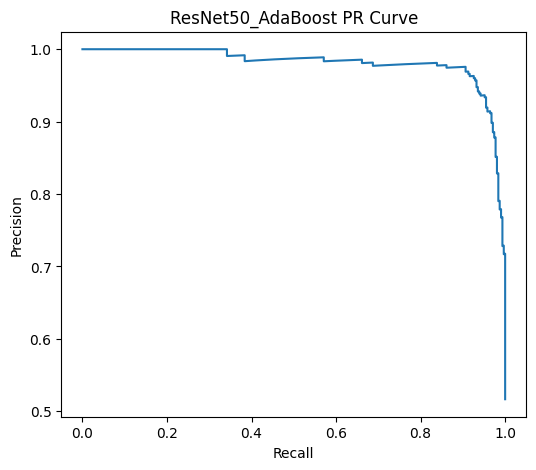

In [16]:
#CELL 14 — Final Pipeline
all_results = {}

cnn_models = [
    'EfficientNetB0',
    'VGG16',
    'ResNet50'
]

for cnn_name in cnn_models:

    print(f"\nRunning {cnn_name}")

    train_features, val_features = extract_features(
        cnn_name
    )

    train_selected, val_selected = apply_mrmr(
        train_features,
        y_train,
        val_features
    )

    for ml_name, ml_model in ml_models.items():

        print(f"\n{cnn_name} + {ml_name}")

        ml_model.fit(
            train_selected,
            y_train
        )

        pred = ml_model.predict(
            val_selected
        )

        prob = ml_model.predict_proba(
            val_selected
        )

        result_key = cnn_name + '_' + ml_name

        acc = calculate_metrics(
            y_val,
            pred,
            prob,
            result_key
        )

        all_results[result_key] = acc

75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 393ms/step


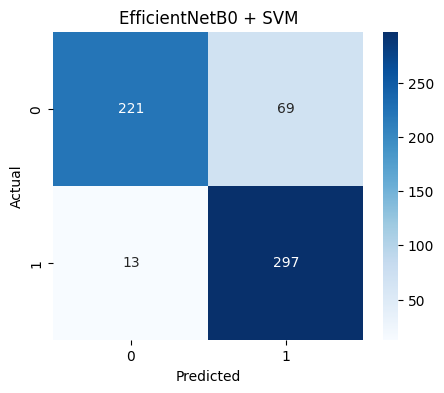

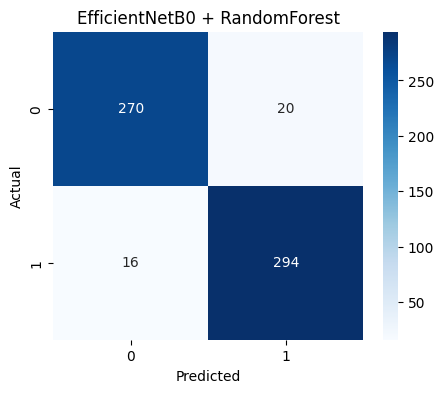

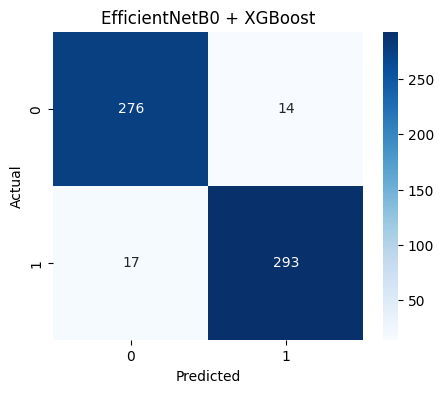

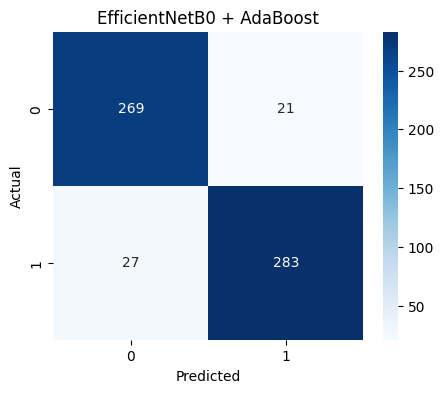

75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step


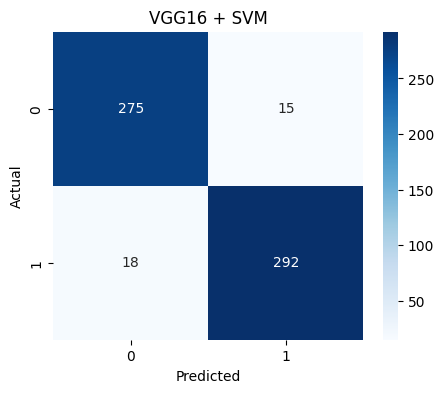

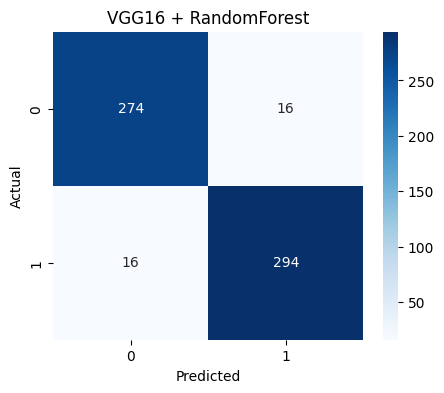

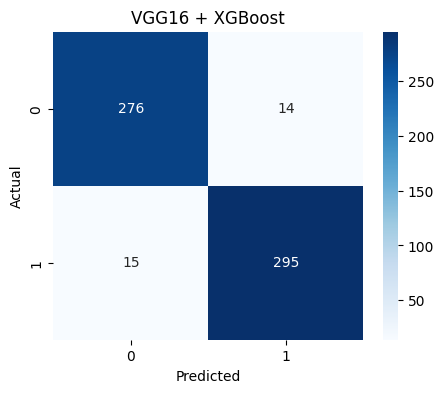

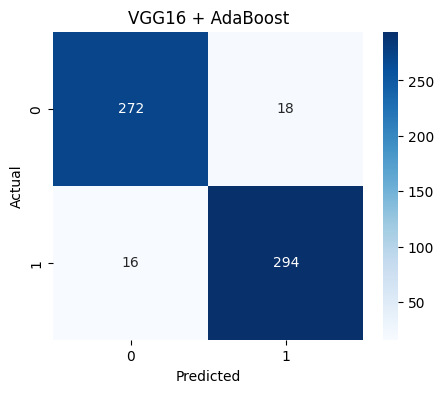

75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step


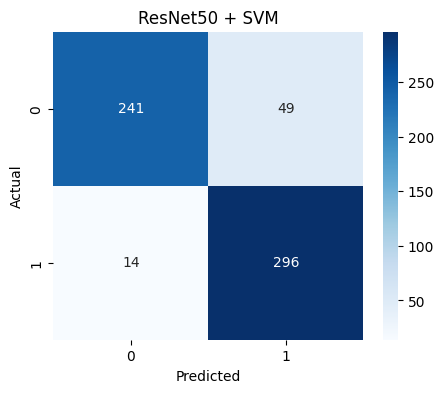

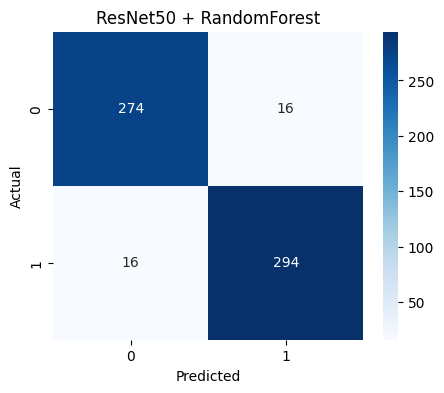

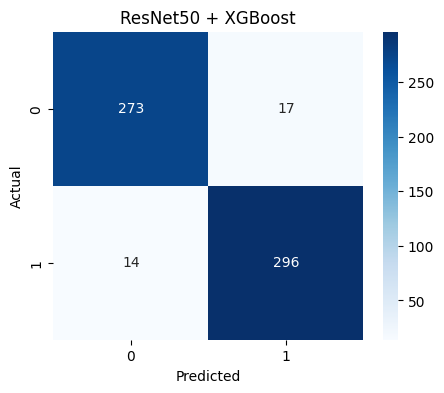

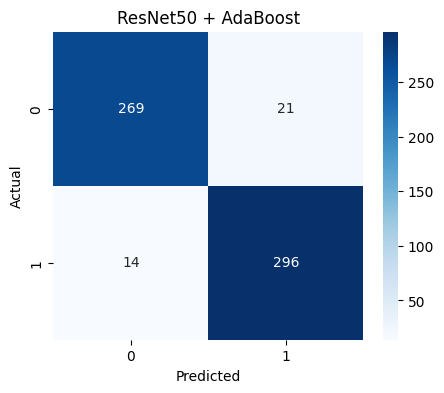

In [17]:
#Confusion matrix plot
for cnn_name in cnn_models:

    train_features, val_features = extract_features(
        cnn_name
    )

    train_selected, val_selected = apply_mrmr(
        train_features,
        y_train,
        val_features
    )

    for ml_name, ml_model in ml_models.items():

        model = ml_model

        model.fit(
            train_selected,
            y_train
        )

        pred = model.predict(
            val_selected
        )

        cm = confusion_matrix(
            y_val,
            pred
        )

        plt.figure(figsize=(5,4))

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues'
        )

        plt.xlabel("Predicted")

        plt.ylabel("Actual")

        plt.title(
            cnn_name + " + " + ml_name
        )

        plt.show()

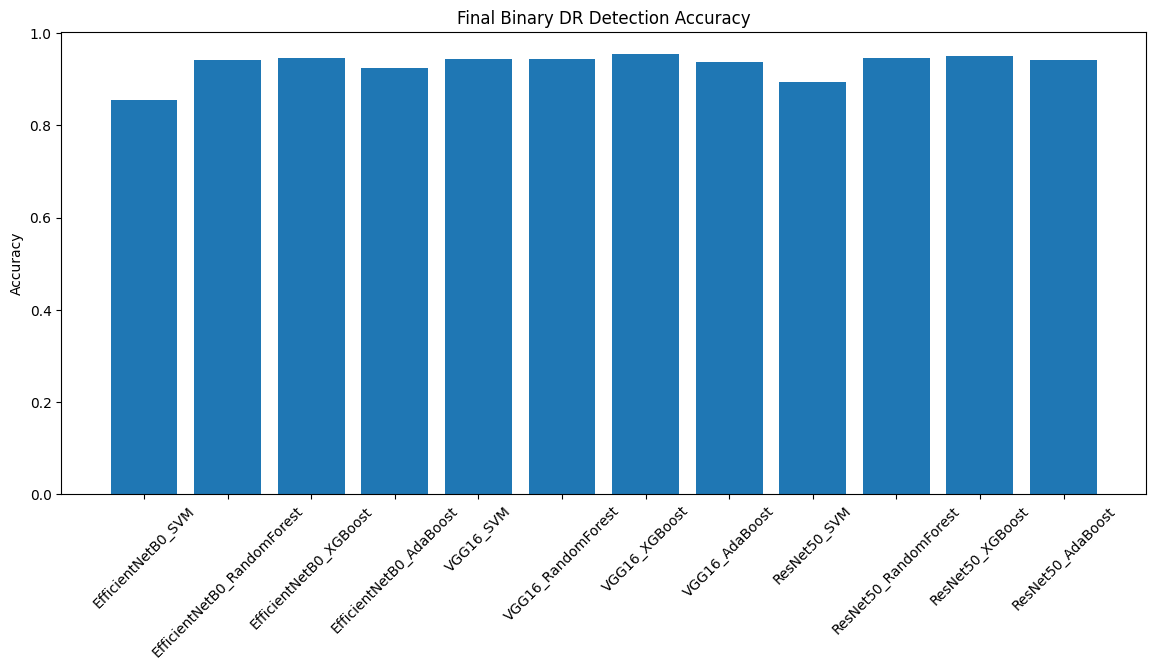

In [18]:
#CELL 15 — Final Accuracy Graph
plt.figure(figsize=(14,6))

plt.bar(
    all_results.keys(),
    all_results.values()
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Final Binary DR Detection Accuracy")

plt.show()

In [ ]:
# Used Methodologies
#1 - Transfer Learning
#2 - CNN-based Feature Extraction
#3 - Image Preprocessing
#4 - Binary Classification
#5 - Feature Flattening
#6 - Feature Selection (MRMR-style / SelectKBest)
#7 - Hybrid Deep Learning + Machine Learning
#8 - Ensemble Learning
#9 - Boosting
#10 - Stratified Train-Test Splitting
#11 - Performance Evaluation Metrics
#12 - ROC-AUC Analysis
#13 - Precision-Recall Analysis
#14 - Confusion Matrix Analysis
#15 - Comparative Model Evaluation